In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [ ]:
df = pd.read_csv('dataset_ML.csv')

print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Total data: {len(df)}")
print(f"\nKolom: {df.columns.tolist()}")
print(f"\nDistribusi Label:")
print(df['label'].value_counts())
print(f"\nStatistik Deskriptif:")
print(df[['suhu_inkubator', 'kelembapan']].describe())

# Prepare features and target
X = df[['suhu_inkubator', 'kelembapan']]
y = df['label']

DATASET INFO
Total data: 412

Kolom: ['timestamp', 'suhu_inkubator', 'kelembapan', 'label']

Distribusi Label:
label
dingin    191
panas     137
normal     84
Name: count, dtype: int64

Statistik Deskriptif:
       suhu_inkubator  kelembapan
count      412.000000  412.000000
mean        38.941019   53.395631
std          2.722537    6.607250
min         34.700000   34.000000
25%         36.900000   50.000000
50%         38.250000   54.500000
75%         40.100000   58.000000
max         48.200000   67.000000


In [ ]:
# Split data: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)
print(f"\n{'=' * 60}")
print("DATA SPLITTING")
print("=" * 60)
print(f"Train set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")


DATA SPLITTING
Train set: 288 samples (69.9%)
Validation set: 62 samples (15.0%)
Test set: 62 samples (15.0%)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

print(f"\n{'=' * 60}")
print("TRAINING MODEL")
print("=" * 60)
rf_model.fit(X_train, y_train)
print("✓ Model berhasil dilatih!")


TRAINING MODEL
✓ Model berhasil dilatih!


In [ ]:
y_val_pred = rf_model.predict(X_val)
val_accuracy = rf_model.score(X_val, y_val)

print(f"\n{'=' * 60}")
print("VALIDATION SET RESULTS")
print("=" * 60)
print(f"Accuracy: {val_accuracy*100:.2f}%\n")
print(classification_report(y_val, y_val_pred, target_names=['dingin', 'normal', 'panas']))

# Evaluate on test set
y_test_pred = rf_model.predict(X_test)
test_accuracy = rf_model.score(X_test, y_test)

print(f"\n{'=' * 60}")
print("TEST SET RESULTS (FINAL EVALUATION)")
print("=" * 60)
print(f"Accuracy: {test_accuracy*100:.2f}%\n")
print(classification_report(y_test, y_test_pred, target_names=['dingin', 'normal', 'panas']))


VALIDATION SET RESULTS
Accuracy: 100.00%

              precision    recall  f1-score   support

      dingin       1.00      1.00      1.00        29
      normal       1.00      1.00      1.00        12
       panas       1.00      1.00      1.00        21

    accuracy                           1.00        62
   macro avg       1.00      1.00      1.00        62
weighted avg       1.00      1.00      1.00        62


TEST SET RESULTS (FINAL EVALUATION)
Accuracy: 100.00%

              precision    recall  f1-score   support

      dingin       1.00      1.00      1.00        29
      normal       1.00      1.00      1.00        13
       panas       1.00      1.00      1.00        20

    accuracy                           1.00        62
   macro avg       1.00      1.00      1.00        62
weighted avg       1.00      1.00      1.00        62




CONFUSION MATRIX
[[29  0  0]
 [ 0 13  0]
 [ 0  0 20]]

✓ Confusion matrix disimpan sebagai 'confusion_matrix.png'

FEATURE IMPORTANCE
          feature  importance
0  suhu_inkubator    0.608588
1      kelembapan    0.391412


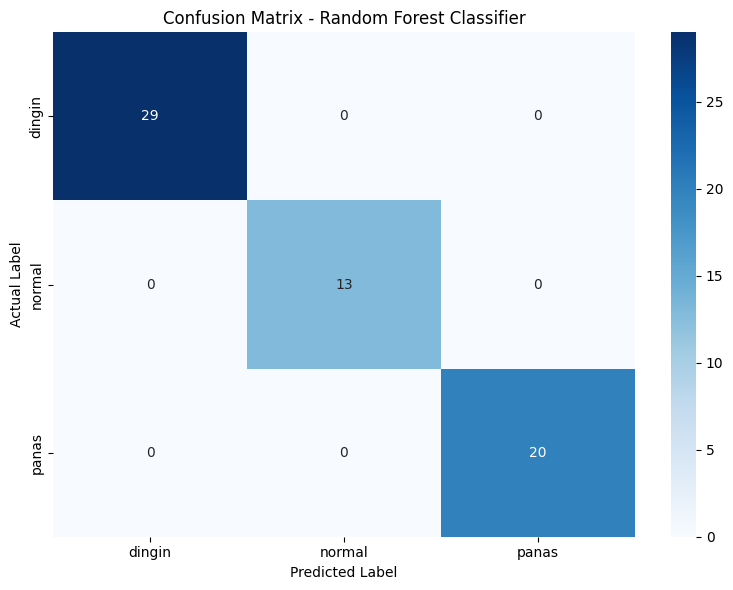

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n{'=' * 60}")
print("CONFUSION MATRIX")
print("=" * 60)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['dingin', 'normal', 'panas'],
            yticklabels=['dingin', 'normal', 'panas'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix disimpan sebagai 'confusion_matrix.png'")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': ['suhu_inkubator', 'kelembapan'],
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n{'=' * 60}")
print("FEATURE IMPORTANCE")
print("=" * 60)
print(feature_importance)

In [ ]:
# Save model to pickle
model_filename = 'model_inkubator.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(rf_model, f)

print(f"\n{'=' * 60}")
print("MODEL SAVED")
print("=" * 60)
print(f"✓ Model berhasil disimpan sebagai '{model_filename}'")
print(f"\nModel siap untuk digunakan dalam prediksi real-time dan integrasi IoT-MQTT!")

# Example prediction
print(f"\n{'=' * 60}")
print("CONTOH PREDIKSI")
print("=" * 60)
example_data = [[37.5, 65], [32.0, 50], [40.0, 70]]
predictions = rf_model.predict(example_data)

for i, (data, pred) in enumerate(zip(example_data, predictions)):
    print(f"Data {i+1}: Suhu={data[0]}°C, Kelembapan={data[1]}% → Prediksi: {pred}")


MODEL SAVED
✓ Model berhasil disimpan sebagai 'model_inkubator.pkl'

Model siap untuk digunakan dalam prediksi real-time dan integrasi IoT-MQTT!

CONTOH PREDIKSI
Data 1: Suhu=37.5°C, Kelembapan=65% → Prediksi: normal
Data 2: Suhu=32.0°C, Kelembapan=50% → Prediksi: dingin
Data 3: Suhu=40.0°C, Kelembapan=70% → Prediksi: panas


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Trees:  10 | Train: 0.9965 | Val: 1.0000
Trees:  20 | Train: 0.9965 | Val: 1.0000
Trees:  30 | Train: 0.9965 | Val: 1.0000
Trees:  40 | Train: 0.9965 | Val: 1.0000
Trees:  50 | Train: 0.9965 | Val: 1.0000
Trees:  60 | Train: 0.9965 | Val: 1.0000
Trees:  70 | Train: 0.9965 | Val: 1.0000
Trees:  80 | Train: 0.9965 | Val: 1.0000
Trees:  90 | Train: 0.9965 | Val: 1.0000
Trees: 100 | Train: 0.9965 | Val: 1.0000


(0.0, 1.05)

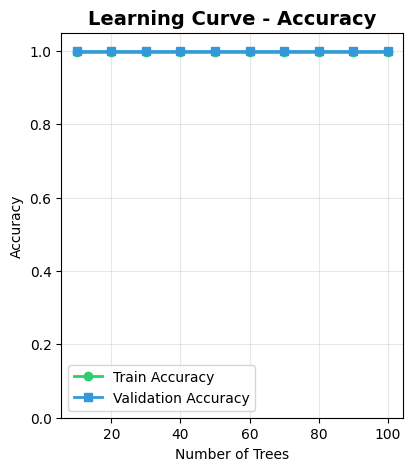

In [ ]:
training_history = {
    'n_estimators': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'train_loss': [],
    'val_loss': []
}

# Train incrementally
estimator_steps = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for n_est in estimator_steps:
    rf_model.n_estimators = n_est
    rf_model.fit(X_train, y_train)

    train_acc = rf_model.score(X_train, y_train)
    val_acc = rf_model.score(X_val, y_val)

    training_history['n_estimators'].append(n_est)
    training_history['train_accuracy'].append(train_acc)
    training_history['val_accuracy'].append(val_acc)
    training_history['train_loss'].append(1 - train_acc)
    training_history['val_loss'].append(1 - val_acc)

    print(f"Trees: {n_est:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

# ==================== GRAFIK GARIS ====================
# Letakkan ini di bagian visualisasi

# 1. Learning Curve - Accuracy
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(training_history['n_estimators'], training_history['train_accuracy'],
         'o-', color='#2ecc71', linewidth=2, markersize=6, label='Train Accuracy')
plt.plot(training_history['n_estimators'], training_history['val_accuracy'],
         's-', color='#3498db', linewidth=2, markersize=6, label='Validation Accuracy')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.05])